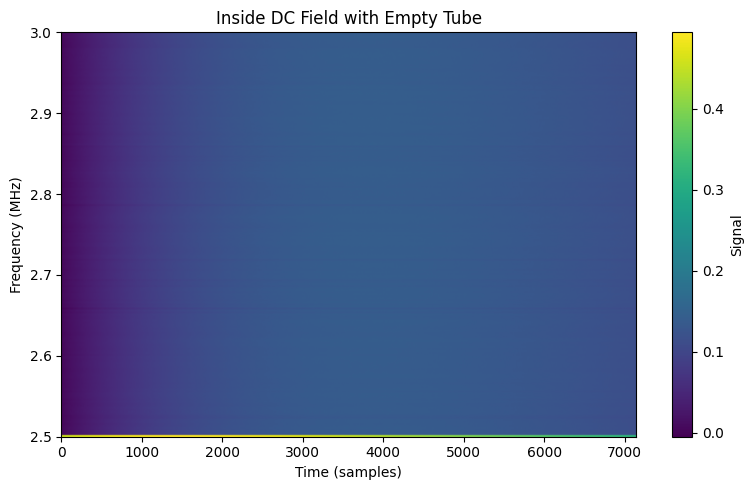

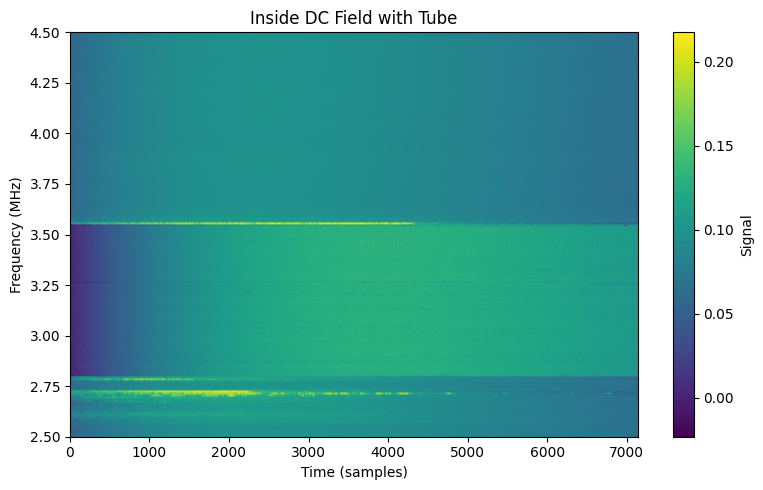

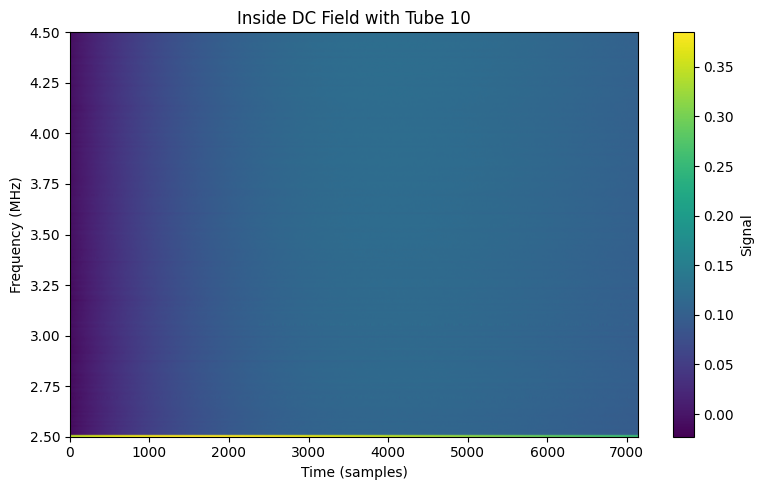

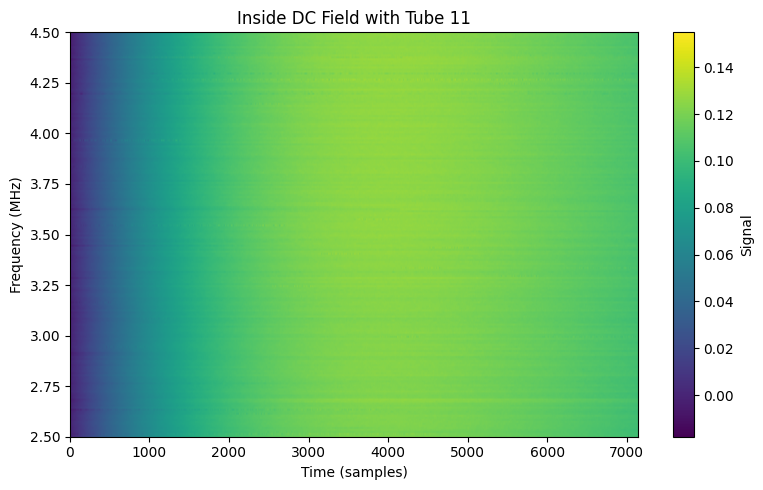

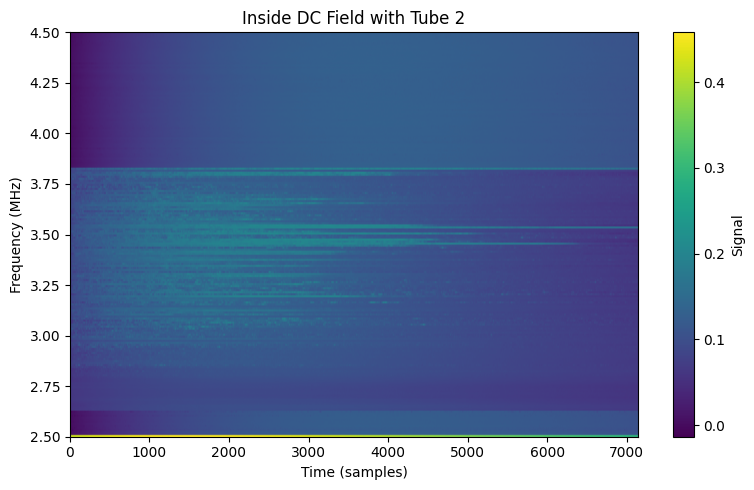

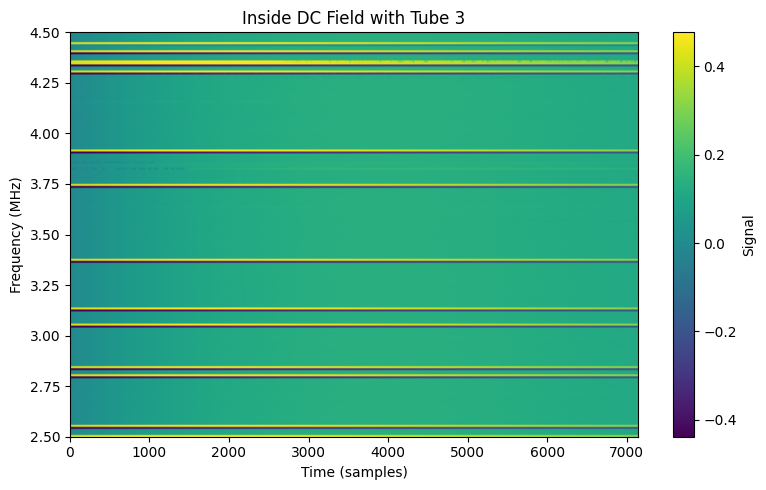

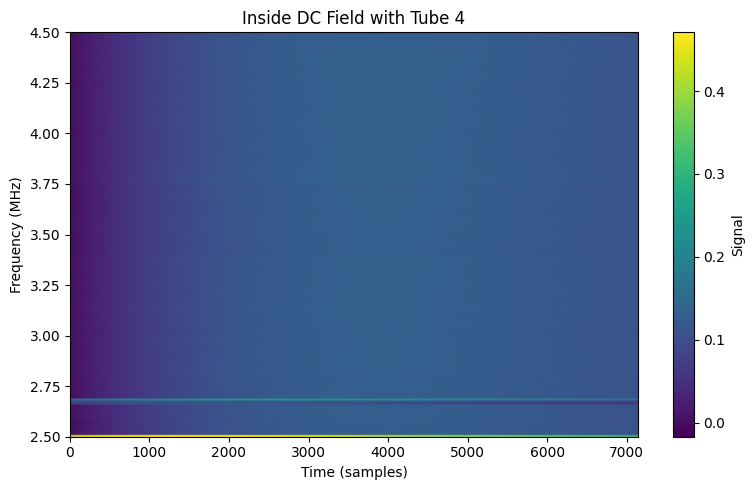

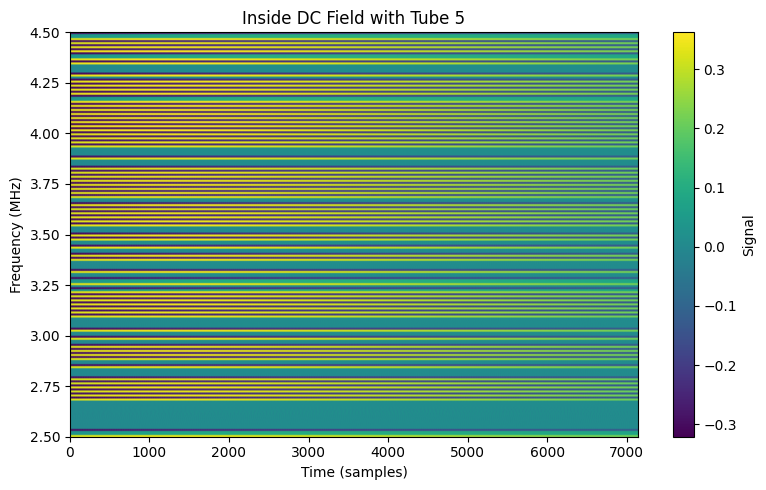

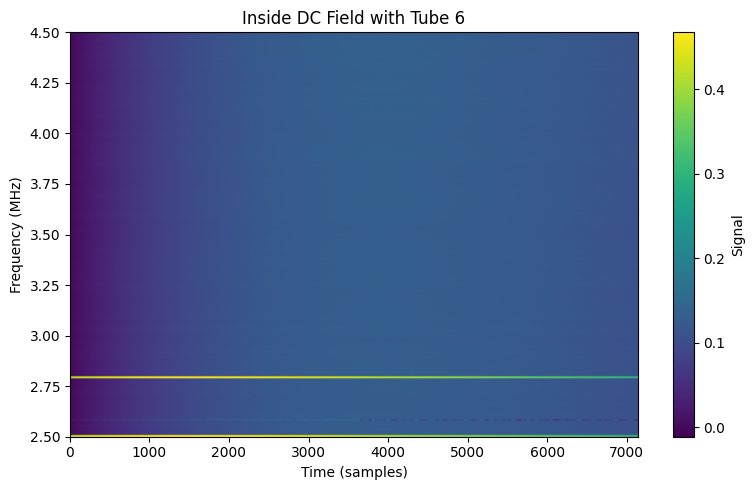

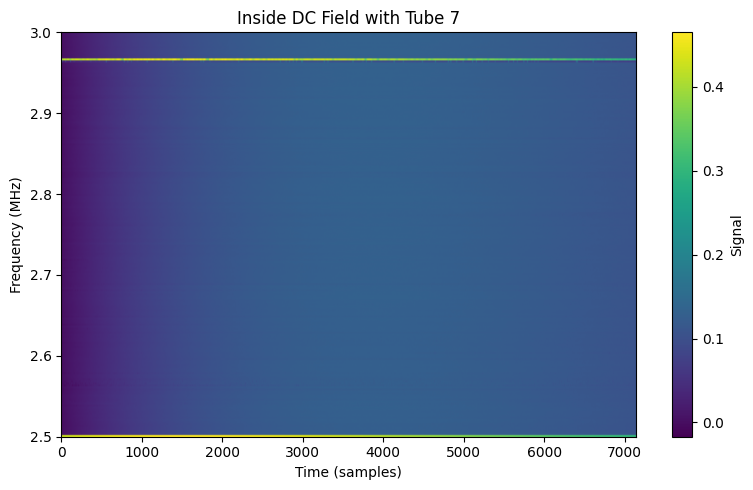

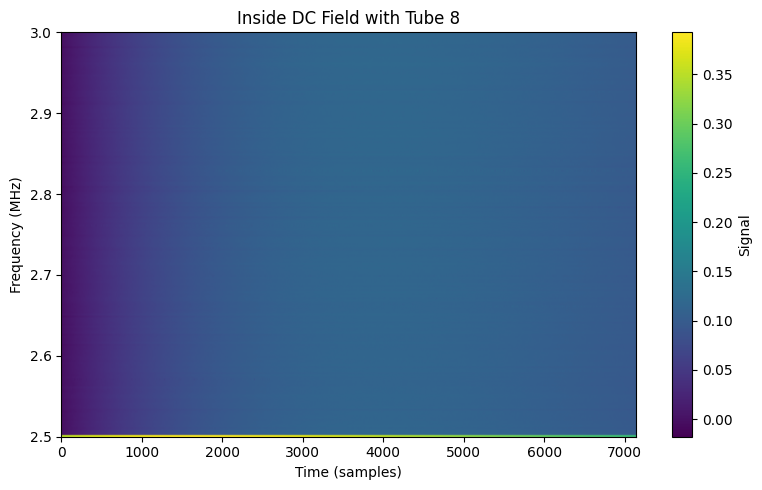

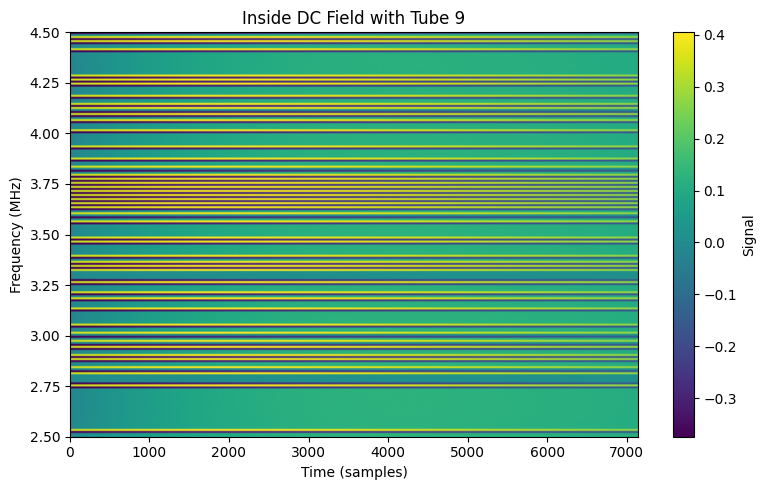

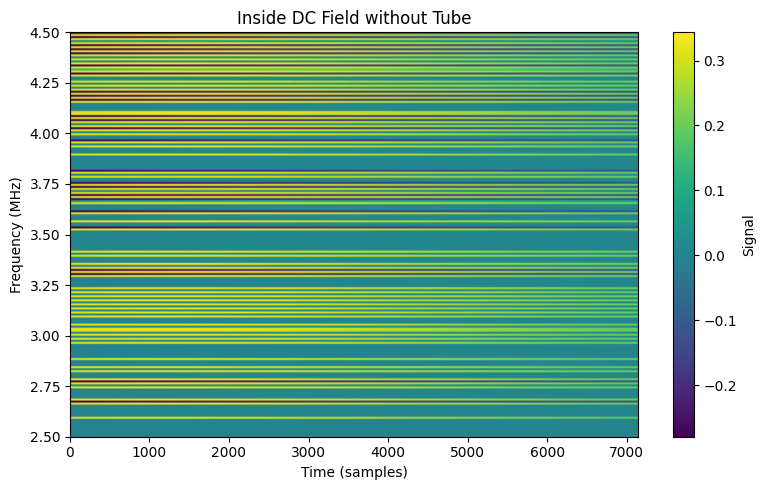

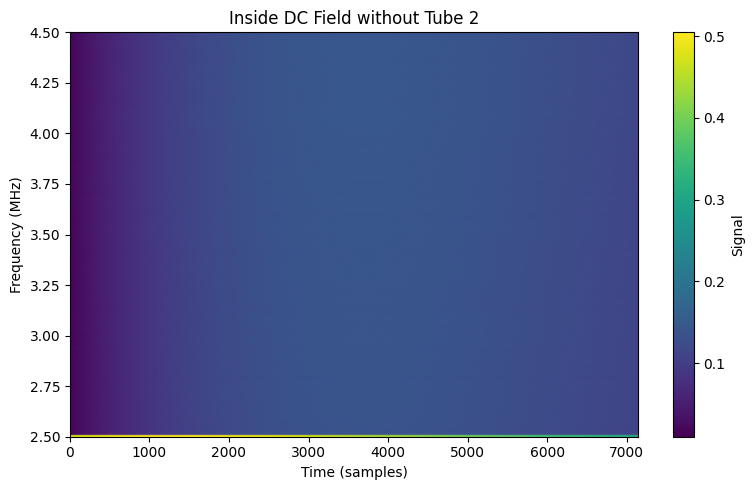

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

root = Path("~/Desktop/pulspin/experiments/FreqTime/outputs").expanduser()

for folder in root.iterdir():
    if not folder.is_dir():
        continue

    files = sorted(folder.glob("*.bin"))
    if not files:
        continue

    freqs = []
    data = []

    for f in files:
        m = re.search(r"f\[(.*?)MHz\]", f.name)
        if m:
            freqs.append(float(m.group(1)))
            data.append(np.fromfile(f, dtype=np.float64))

    if not data:
        continue

    # sort by frequency
    order = np.argsort(freqs)
    freqs = np.array(freqs)[order]
    data = [data[i] for i in order]

    # trim to shortest trace
    L = min(len(d) for d in data)
    M = np.array([d[:L] for d in data])

    plt.figure(figsize=(8,5))
    plt.imshow(M, aspect='auto', origin='lower',
               extent=[0, L, freqs[0], freqs[-1]])
    plt.colorbar(label="Signal")
    plt.xlabel("Time (samples)")
    plt.ylabel("Frequency (MHz)")
    plt.title(folder.name)
    plt.tight_layout()
    plt.show()